# Import dependencies


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Task 1: Perform point operations


In [31]:
img = cv2.imread('image1.jpg', 0)  # Replace with your image path

# a) Image Negative
negative_img = 255 - img

# b) Log-Transform
c = 255 / np.log(np.max(img + 1))
log_img = c * (np.log(img.astype(np.float32) + 1))
log_img = log_img / 255

# c) Gamma Correction
gamma = 1.2  # Adjust gamma value as needed
gamma_img = np.array(255*(img / 255) ** gamma, dtype = 'uint8')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


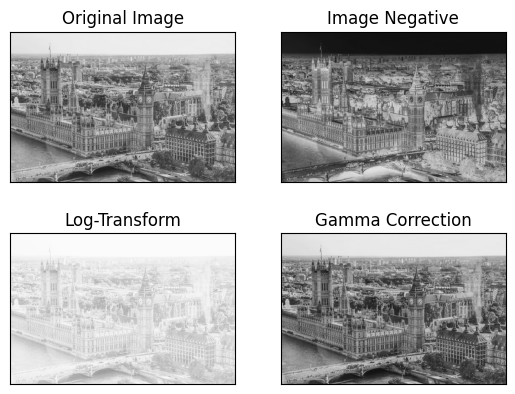

In [32]:
# Plot the responses
titles = ['Original Image', 'Image Negative', 'Log-Transform', 'Gamma Correction']
images = [img, negative_img, log_img, gamma_img]

for i in range(len(images)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

# Task 2: Image Binarization


In [33]:
threshold = 127  # Adjust threshold value as needed
binary_img = np.where(img < threshold, 0, 255)

Text(0.5, 1.0, 'Binarized image')

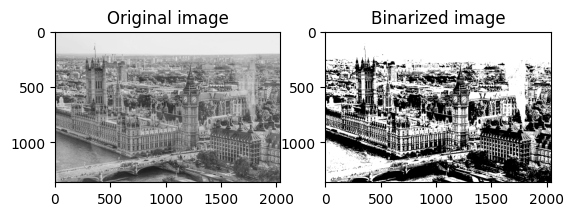

In [35]:
plt.subplot(1, 2, 1)
plt.imshow(img, "gray")
plt.title("Original image")
plt.subplot(1, 2, 2)
plt.imshow(binary_img, "gray")
plt.title("Binarized image")

# Task 3: Contrast Stretching


In [36]:
min_val, max_val, _, _ = cv2.minMaxLoc(img)
contrast_stretched_img = (img - min_val) * (255 / (max_val - min_val))

Text(0.5, 1.0, 'Contrast Stretched image')

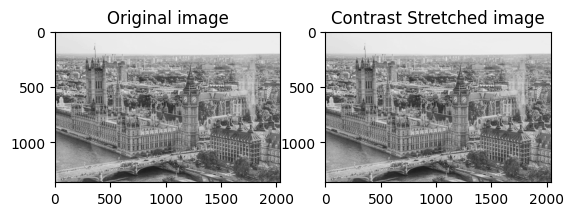

In [39]:
plt.subplot(1, 2, 1)
plt.imshow(img, "gray")
plt.title("Original image")
plt.subplot(1, 2, 2)
plt.imshow(contrast_stretched_img, "gray")
plt.title("Contrast Stretched image")

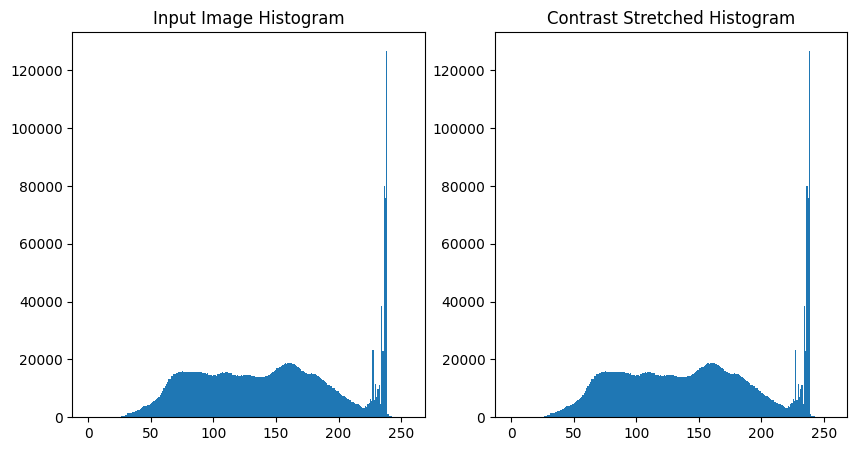

In [38]:
# Plot histograms
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.hist(img.ravel(), 256, [0, 256]), plt.title('Input Image Histogram')
plt.subplot(122), plt.hist(contrast_stretched_img.ravel(), 256, [0, 256]), plt.title('Contrast Stretched Histogram')
plt.show()